In [76]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os

In [77]:
getcwd = os.getcwd()
os.chdir('/Users/ice50l/Downloads')
getcwd

'/Users/ice50l/Downloads'

In [78]:
pd.set_option('display.max_columns', None)
crime = pd.read_csv('Crime_Incidents_in_2024.csv')
crime.head()

,X,Y,CCN,REPORT_DAT,SHIFT,METHOD,OFFENSE,BLOCK,XBLOCK,YBLOCK,WARD,ANC,DISTRICT,PSA,NEIGHBORHOOD_CLUSTER,BLOCK_GROUP,CENSUS_TRACT,VOTING_PRECINCT,LATITUDE,LONGITUDE,BID,START_DATE,END_DATE,OBJECTID,OCTO_RECORD_ID
0,400040.6100,129046.4721,18060158,2024/07/30 04:00:00+00,MIDNIGHT,GUN,HOMICIDE,400 - 599 BLOCK OF CHESAPEAKE STREET SE,400040.610046,129046.472149,8.0,8E,7.0,706.0,Cluster 39,009802 2,9802.0,Precinct 125,38.829204,-76.999532,NaN,2018/04/15 16:07:00+00,2018/04/15 17:34:56+00,688672882,NaN
1,397833.8700,138551.8900,23101994,2024/02/07 18:11:44+00,DAY,OTHERS,THEFT F/AUTO,900 - 999 BLOCK OF WESTMINSTER STREET NW,397833.870000,138551.890000,1.0,1B,3.0,305.0,Cluster 3,004402 2,4402.0,Precinct 137,38.914830,-77.024977,NaN,2023/06/25 07:34:00+00,2023/06/25 08:09:00+00,688697908,NaN
2,397576.9900,143086.8500,20160181,2024/05/22 04:00:00+00,MIDNIGHT,GUN,HOMICIDE,5401 - 5499 BLOCK OF GEORGIA AVENUE NW,397576.990000,143086.850000,4.0,4D,4.0,403.0,Cluster 18,002101 5,2101.0,Precinct 56,38.955682,-77.027955,NaN,2020/11/09 02:03:53+00,2020/11/09 02:20:49+00,688947135,NaN
3,399337.0100,138221.0900,21151970,2024/06/20 04:00:00+00,MIDNIGHT,GUN,HOMICIDE,2 - 99 BLOCK OF QUINCY PLACE NE,399337.010000,138221.090000,5.0,5F,5.0,502.0,Cluster 21,008701 1,8701.0,Precinct 75,38.911853,-77.007644,NaN,2021/10/19 01:53:00+00,2021/10/19 07:56:00+00,688957976,NaN
4,400891.3397,131932.5347,22065374,2024/05/22 04:00:00+00,MIDNIGHT,GUN,HOMICIDE,2400 - 2699 BLOCK OF POMEROY ROAD SE,400891.339743,131932.534680,8.0,8B,7.0,703.0,Cluster 37,007406 2,7406.0,Precinct 118,38.855203,-76.989731,NaN,2022/05/10 13:30:00+00,2022/05/10 14:15:00+00,688963056,NaN


In [79]:
df = crime.copy()

df['REPORT_DAT'] = pd.to_datetime(df['REPORT_DAT'])

df['year'] = df['REPORT_DAT'].dt.year

df.groupby('year')['OBJECTID'].count().reset_index()

,year,OBJECTID
0,2024,29274
1,2025,20


In [80]:
df.dtypes

X                                   float64
Y                                   float64
CCN                                   int64
REPORT_DAT              datetime64[ns, UTC]
SHIFT                                object
METHOD                               object
OFFENSE                              object
BLOCK                                object
XBLOCK                              float64
YBLOCK                              float64
WARD                                float64
ANC                                  object
DISTRICT                            float64
PSA                                 float64
NEIGHBORHOOD_CLUSTER                 object
BLOCK_GROUP                          object
CENSUS_TRACT                        float64
VOTING_PRECINCT                      object
LATITUDE                            float64
LONGITUDE                           float64
BID                                  object
START_DATE                           object
END_DATE                        

In [81]:
#This code is used to convert data types into the appropriate format. 

df['START_DATE'] = pd.to_datetime(df['START_DATE'])
df['END_DATE'] = pd.to_datetime(df['END_DATE'])


df['WARD'] = df['WARD'].astype('Int64')
df['DISTRICT'] = df['DISTRICT'].astype('Int64')
df['PSA'] = df['PSA'].astype('Int64')


df['CENSUS_TRACT'] = df['CENSUS_TRACT'].astype(str)


df['ANC'] = df['ANC'].astype('category')
df['VOTING_PRECINCT'] = df['VOTING_PRECINCT'].astype('category')


In [82]:
df.dtypes

X                                   float64
Y                                   float64
CCN                                   int64
REPORT_DAT              datetime64[ns, UTC]
SHIFT                                object
METHOD                               object
OFFENSE                              object
BLOCK                                object
XBLOCK                              float64
YBLOCK                              float64
WARD                                  Int64
ANC                                category
DISTRICT                              Int64
PSA                                   Int64
NEIGHBORHOOD_CLUSTER                 object
BLOCK_GROUP                          object
CENSUS_TRACT                         object
VOTING_PRECINCT                    category
LATITUDE                            float64
LONGITUDE                           float64
BID                                  object
START_DATE              datetime64[ns, UTC]
END_DATE                datetime

In [83]:
print(f'The number of rows for this dataset is {df.shape[0]}.\nThe number of columns is {df.shape[1]}')

The number of rows for this dataset is 29294.
The number of columns is 26


In [84]:
df.groupby('SHIFT')['OBJECTID'].count().reset_index()

,SHIFT,OBJECTID
0,DAY,11507
1,EVENING,11848
2,MIDNIGHT,5939


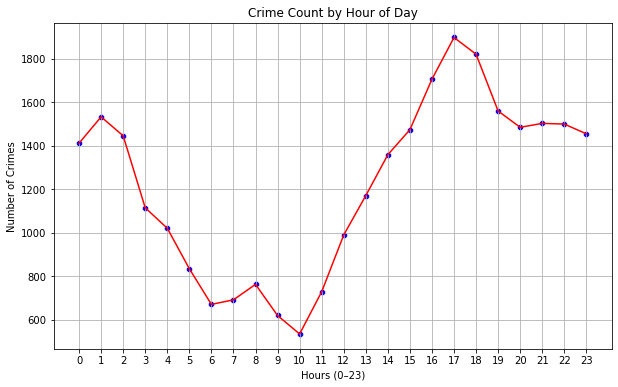

In [ ]:
#Used this code to visualize the number of crimes by hour.
df['hour'] = pd.to_datetime(df['REPORT_DAT'], errors='coerce').dt.hour

hourly_counts = df.groupby('hour').size().reset_index(name='crime_count')

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=hourly_counts, x='hour', y='crime_count', color='blue')
sns.lineplot(data=hourly_counts, x='hour', y='crime_count', color='red') 
plt.title("Crime Count by Hour of Day")
plt.xlabel("Hours (0–23)")
plt.ylabel("Number of Crimes")
plt.xticks(range(0, 24))
plt.grid(True)
plt.show()

In [86]:
hourly_counts

,hour,crime_count
0,0,1412
1,1,1533
2,2,1446
3,3,1115
4,4,1021
5,5,835
6,6,671
7,7,692
8,8,763
9,9,620


In [87]:
district_offense = df.groupby(["DISTRICT", "OFFENSE"]).size().reset_index(name="crime_count")
district_offense = district_offense.dropna()
district_offense = district_offense.sort_values(by="crime_count", ascending=False).head(5)
district_offense


,DISTRICT,OFFENSE,crime_count
17,2,THEFT/OTHER,3492
25,3,THEFT/OTHER,2577
8,1,THEFT/OTHER,1708
41,5,THEFT/OTHER,1636
33,4,THEFT/OTHER,1491


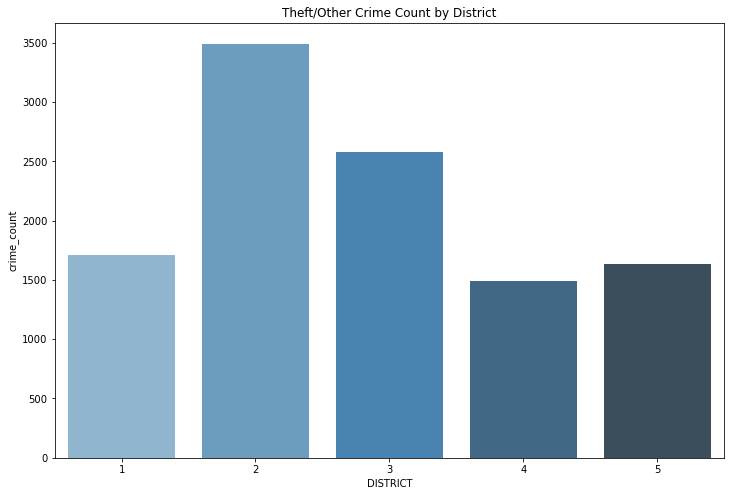

In [88]:
plt.figure(figsize = (12,8))
sns.barplot(data=district_offense, x="DISTRICT", y="crime_count", palette="Blues_d")
plt.title('Theft/Other Crime Count by District')
plt.show()


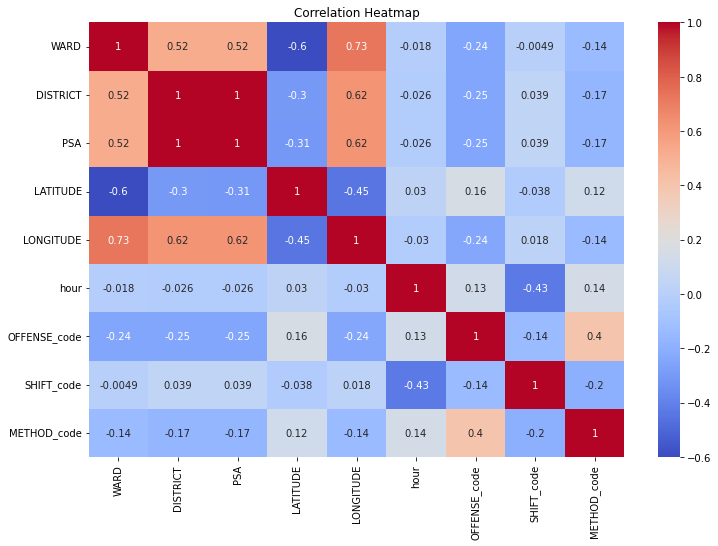

In [ ]:
#Factorized the categories so they can be visualized in the heatmap. Otherwise it woould not show up. 
df['OFFENSE'] = df['OFFENSE'].astype('category')
df['SHIFT'] = df['SHIFT'].astype('category')
df['METHOD'] = df['METHOD'].astype('category')

df['OFFENSE_code'] = df['OFFENSE'].cat.codes
df['SHIFT_code'] = df['SHIFT'].cat.codes
df['METHOD_code'] = df['METHOD'].cat.codes


plt.figure(figsize=(12, 8))
fields = ["WARD", "DISTRICT", "PSA", "LATITUDE", "LONGITUDE", "hour", 'OFFENSE_code', 'SHIFT_code', 'METHOD_code']
df_subset = df[fields].dropna()
sns.heatmap(df_subset.corr(), annot=True, cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()
